## **`Notebook 2: Job Title vs Salary Keyword Analysis`**


## **1. Importing libraries**


In [1]:
import pandas as pd
import numpy as np

import re
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
from wordcloud import WordCloud

## **2. Loading hourly and fixed datasets**

In [2]:
hourly_df = pd.read_csv(r"D:\Project 8\cleaned_jobs.csv")
fixed_df = pd.read_csv(r"D:\Project 8\fixed_jobs.csv")

## **3. Checking salary columns**

In [3]:
hourly_df[["hourly_low", "hourly_high", "avg_hourly_rate"]].describe()
fixed_df["budget"].describe()

count     103891.000000
mean         911.473564
std        15729.738834
min            5.000000
25%           25.000000
50%          100.000000
75%          300.000000
max      1000000.000000
Name: budget, dtype: float64

## **4. Tokenize job titles**

In [4]:
stopwords = {
    "and", "for", "with", "to", "in", "of", "a", "an", "the",
    "needed", "need", "expert", "specialist", "wanted"
}

def extract_keywords(title):
    words = str(title).lower().split()
    words = [w for w in words if w not in stopwords and len(w) > 2]
    return words

hourly_df["keywords"] = hourly_df["clean_title"].apply(extract_keywords)

## **5. Explode keywords**

In [5]:
keyword_df = hourly_df.explode("keywords")
keyword_df = keyword_df.dropna(subset=["keywords", "avg_hourly_rate"])

## **6. Keyword frequency**

In [6]:
keyword_counts = keyword_df["keywords"].value_counts().reset_index()
keyword_counts.columns = ["keyword", "count"]
keyword_counts.head(20)

,keyword,count
0,developer,7452
1,website,5828
2,designer,5483
3,video,4683
4,design,4552
5,amp,4363
6,marketing,4326
7,media,4168
8,social,3854
9,assistant,3775


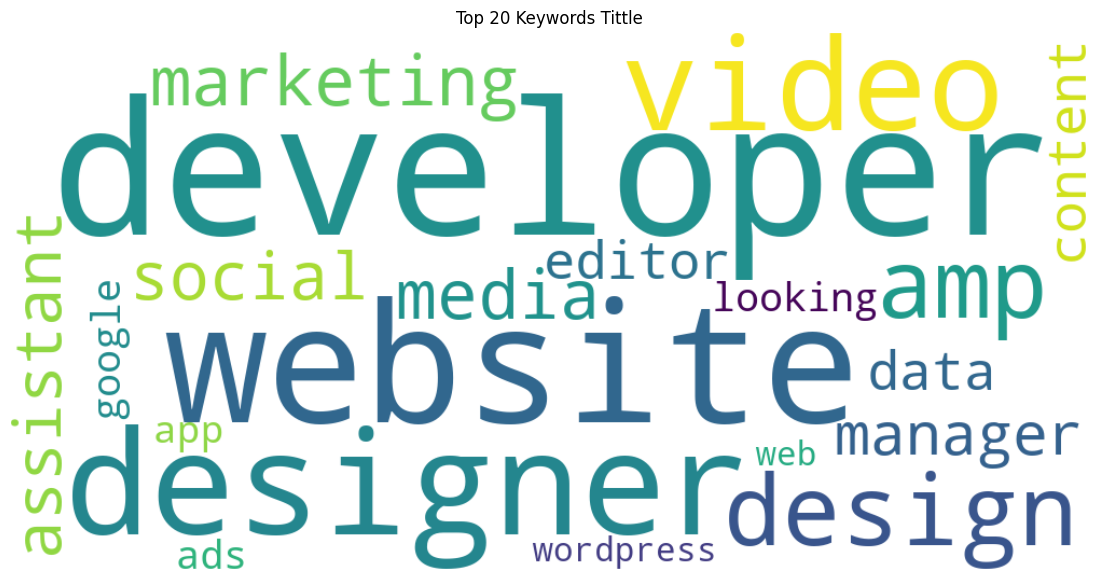

In [7]:
top_keywords = keyword_counts.head(20)

word_freq = dict(zip(top_keywords["keyword"], top_keywords["count"]))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    colormap='viridis'
).generate_from_frequencies(word_freq)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Top 20 Keywords Tittle")

plt.show()

In [8]:
# Sort data
top_keywords = keyword_counts.sort_values(by="count", ascending=False).head(20)

fig = px.bar(
    top_keywords,
    x="count",
    y="keyword",
    orientation='h',
    title="Top 20 Keywords by Frequency",
    text="count"
)

# Make highest on top
fig.update_layout(
    yaxis={'categoryorder':'total ascending'},
    title_x=0.5
)

fig.show()

## **7. Average hourly rate by keyword**

In [9]:
keyword_salary = (
    keyword_df.groupby("keywords")["avg_hourly_rate"]
    .agg(["count", "mean", "median"])
    .reset_index()
    .rename(columns={"keywords": "keyword"})
)

keyword_salary = keyword_salary[keyword_salary["count"] >= 50]
keyword_salary = keyword_salary.sort_values("mean", ascending=False)
keyword_salary.head(20)

,keyword,count,mean,median
12398,independent,102,261.926471,350.00
18980,procedures,55,112.781818,130.00
1712,also,60,111.566667,132.50
2629,attorney,181,101.455801,107.50
13842,lawyer,203,92.145320,92.50
1502,agreement,80,90.693750,94.50
17726,patent,74,88.986486,95.00
13326,just,51,86.833333,110.00
24682,trademark,64,83.648438,97.50
4113,but,59,83.593220,40.00


## **8. Visualizations**

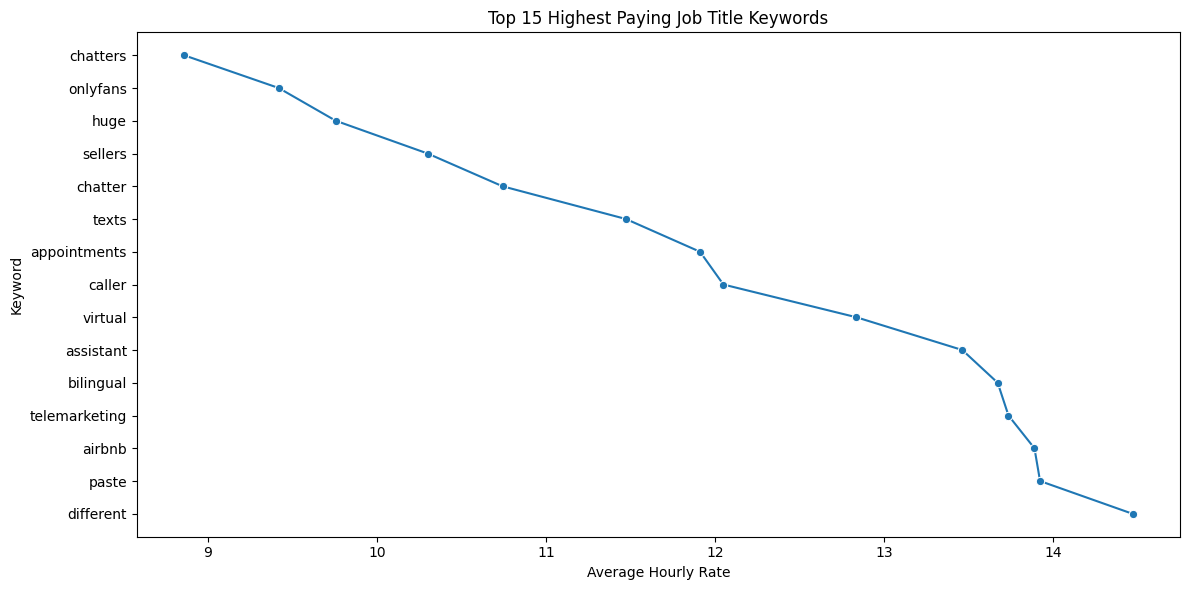

In [10]:
# Sort data for better line flow
top_paid = keyword_salary.sort_values(by="mean", ascending=True).head(15)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=top_paid,
    x="mean",
    y="keyword",
    marker="o"
)

plt.title("Top 15 Highest Paying Job Title Keywords")
plt.xlabel("Average Hourly Rate")
plt.ylabel("Keyword")

plt.tight_layout()
plt.show()

## **9. Comparing common keywords**

In [11]:
common_keywords = keyword_counts[keyword_counts["count"] >= 500]["keyword"]
common_keyword_salary = keyword_salary[keyword_salary["keyword"].isin(common_keywords)]
common_keyword_salary.sort_values("mean", ascending=False).head(20)

,keyword,count,mean,median
23928,tax,663,55.871795,50.00
9832,financial,551,55.324864,37.50
5830,consultant,835,51.228144,40.50
26802,work,979,49.648621,25.00
4322,can,608,48.537007,26.00
22182,simple,703,39.161451,21.00
20337,remote,700,38.490714,25.00
21711,senior,911,38.004391,32.50
8701,engineer,1479,37.625085,32.50
23085,startup,550,37.622727,30.00


## **10. Fixed-price job keyword analysis**


In [12]:
fixed_df["keywords"] = fixed_df["clean_title"].apply(extract_keywords)

fixed_keyword_df = fixed_df.explode("keywords").dropna(subset=["keywords", "budget"])

fixed_keyword_budget = (
    fixed_keyword_df.groupby("keywords")["budget"]
    .agg(["count", "mean", "median"])
    .reset_index()
    .rename(columns={"keywords": "keyword"})
)
fixed_keyword_budget = fixed_keyword_budget[fixed_keyword_budget["count"] >= 50]

fixed_keyword_budget.sort_values("mean", ascending=False).head(20)

,keyword,count,mean,median
21416,profit,52,19826.500000,100.0
16558,mail,56,18260.089286,50.0
13167,head,68,15962.411765,100.0
19290,opportunities,68,15250.514706,250.0
6363,closer,108,14164.342593,500.0
23136,retail,79,12237.025316,300.0
27174,ticket,161,10349.906832,1000.0
24263,selling,84,9922.500000,125.0
22808,removal,103,9870.776699,30.0
19861,partnership,120,9838.525000,100.0


## **11. Saving the outputs**

In [13]:
keyword_salary.to_csv("keyword_hourly_salary_summary.csv", index=False)
fixed_keyword_budget.to_csv("keyword_fixed_budget_summary.csv", index=False)